# MNIST fashion DNN

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


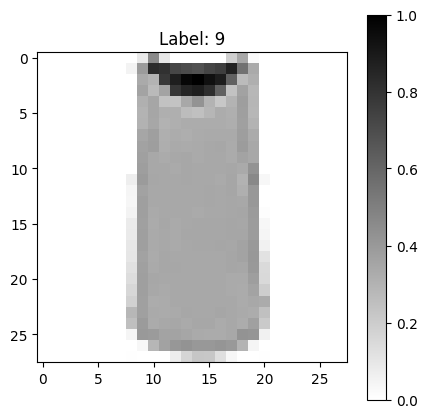

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

# 데이터 로드
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 데이터 전처리: 픽셀 값을 0~1 사이로 정규화
# 딥러닝 모델은 보통 0~1 사이의 값을 입력으로 받을 때 학습이 더 잘 됩니다.
x_train, x_test = x_train / 255.0, x_test / 255.0


# 샘플 이미지 확인
plt.figure(figsize=(5, 5))
plt.imshow(x_train[2], cmap=plt.cm.binary)
plt.title(f"Label: {y_train[0]}")
plt.colorbar()
plt.show()


In [2]:
# DNN 모델 구성
model_dnn = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [3]:
# 컴파일
model_dnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_dnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# 학습
history_dnn = model_dnn.fit(x_train, y_train, epochs=10,
                            validation_split=0.1, batch_size=128, verbose=2)

Epoch 1/10
422/422 - 7s - 16ms/step - accuracy: 0.7709 - loss: 0.6394 - val_accuracy: 0.8460 - val_loss: 0.4198
Epoch 2/10
422/422 - 2s - 4ms/step - accuracy: 0.8434 - loss: 0.4377 - val_accuracy: 0.8548 - val_loss: 0.3924
Epoch 3/10
422/422 - 2s - 5ms/step - accuracy: 0.8568 - loss: 0.3960 - val_accuracy: 0.8638 - val_loss: 0.3649
Epoch 4/10
422/422 - 1s - 3ms/step - accuracy: 0.8632 - loss: 0.3764 - val_accuracy: 0.8722 - val_loss: 0.3411
Epoch 5/10
422/422 - 1s - 3ms/step - accuracy: 0.8698 - loss: 0.3562 - val_accuracy: 0.8740 - val_loss: 0.3450
Epoch 6/10
422/422 - 1s - 3ms/step - accuracy: 0.8751 - loss: 0.3429 - val_accuracy: 0.8810 - val_loss: 0.3343
Epoch 7/10
422/422 - 1s - 3ms/step - accuracy: 0.8772 - loss: 0.3320 - val_accuracy: 0.8805 - val_loss: 0.3241
Epoch 8/10
422/422 - 1s - 3ms/step - accuracy: 0.8819 - loss: 0.3204 - val_accuracy: 0.8792 - val_loss: 0.3143
Epoch 9/10
422/422 - 1s - 3ms/step - accuracy: 0.8828 - loss: 0.3166 - val_accuracy: 0.8820 - val_loss: 0.3083


In [5]:
# 평가
test_loss, test_acc = model_dnn.evaluate(x_test, y_test, verbose=2)
print(f"DNN Test Accuracy: {test_acc:.4f}")

313/313 - 2s - 6ms/step - accuracy: 0.8771 - loss: 0.3346
DNN Test Accuracy: 0.8771


# MNIST fashion CNN

In [6]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models

# 1 데이터 로드
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [7]:
# 2 정규화
x_train = x_train / 255.0
x_test = x_test / 255.0

In [8]:
# 3 채널 차원 추가 (np.expand_dims 이용)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)


print("x_train shape:", x_train.shape)  # (60000, 28, 28, 1)
print("x_test shape:", x_test.shape)    # (10000, 28, 28, 1)

x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


In [9]:
# 4 CNN 모델 구성
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# 5 컴파일
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [11]:
# 6 학습
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

Epoch 1/10
422/422 - 10s - 23ms/step - accuracy: 0.7726 - loss: 0.6202 - val_accuracy: 0.8488 - val_loss: 0.4088
Epoch 2/10
422/422 - 2s - 5ms/step - accuracy: 0.8588 - loss: 0.3858 - val_accuracy: 0.8737 - val_loss: 0.3364
Epoch 3/10
422/422 - 2s - 5ms/step - accuracy: 0.8787 - loss: 0.3332 - val_accuracy: 0.8883 - val_loss: 0.3014
Epoch 4/10
422/422 - 2s - 4ms/step - accuracy: 0.8906 - loss: 0.2996 - val_accuracy: 0.8952 - val_loss: 0.2818
Epoch 5/10
422/422 - 2s - 4ms/step - accuracy: 0.8974 - loss: 0.2775 - val_accuracy: 0.8945 - val_loss: 0.2865
Epoch 6/10
422/422 - 2s - 4ms/step - accuracy: 0.9041 - loss: 0.2596 - val_accuracy: 0.9060 - val_loss: 0.2494
Epoch 7/10
422/422 - 2s - 4ms/step - accuracy: 0.9100 - loss: 0.2412 - val_accuracy: 0.9088 - val_loss: 0.2461
Epoch 8/10
422/422 - 2s - 4ms/step - accuracy: 0.9134 - loss: 0.2315 - val_accuracy: 0.9063 - val_loss: 0.2608
Epoch 9/10
422/422 - 2s - 5ms/step - accuracy: 0.9181 - loss: 0.2203 - val_accuracy: 0.9183 - val_loss: 0.2355

In [12]:
# 7 평가
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

313/313 - 2s - 7ms/step - accuracy: 0.9142 - loss: 0.2449

✅ Test Accuracy: 0.9142


In [13]:
# 8️⃣ 예측 예시
predictions = model.predict(x_test[:5])
print("예측 결과:", np.argmax(predictions, axis=1))
print("실제 레이블:", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step
예측 결과: [9 2 1 1 6]
실제 레이블: [9 2 1 1 6]
